## **OceanOSSE:** Development Notebook

### **Description:**

Notebook to develop & evaluate the core data pipeline in OceanOSSE.

### **Created By:**

Ollie Tooth (oliver.tooth@noc.ac.uk)

In [1]:
import logging

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

from OceanOSSE.gridding.regridder import IDWRegridder
from OceanOSSE.io.dataloader import NetCDFDataLoader
from OceanOSSE.io.datawriter import NetCDFDataWriter
from OceanOSSE.sampling.sampler import RandomSampler


In [2]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    format="⦿══⦿  OceanOSSE  ⦿══⦿  ║ %(levelname)10s ║ %(asctime)s ║ %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler("OceanOSSE.log"), logging.StreamHandler()],
)

### Example configuration .toml file read as dict

In [3]:
config = {
    "domain": {
        "dimensions": {"lev": "nav_lev", "j": "y", "i": "x"},
        "coordinates": {},
        "mask": "tmask",
        "thickcello": "e3t_0",
        "variables": {
            "tmask": {
                "path": "/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
            "e3t_0": {
                "path": "/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "inputs": {
        "dimensions": {"time": "time_counter", "lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "deptht",
            "time": "time_counter",
        },
        "variables": {
            "thetao_con": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2020*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
            "so_abs": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2020*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "climatology": {
        "read_climatology": True,
        "dimensions": {"month": "month", "lev": "lev", "j": "j", "i": "i"},
        "coordinates": {
            "lat": "lat",
            "lon": "lon",
            "depth": "depth",
            "month": "month",
        },
        "variables": {
            "thetao_con": {
                "path": "/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE/eORCA025_ERA5v1_2000-01_2026-12_climatology.nc",
                "open_kwargs": {"engine": "netcdf4", "chunks": {}},
            },
            "so_abs": {
                "path": "/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE/eORCA025_ERA5v1_2000-01_2026-12_climatology.nc",
                "open_kwargs": {"engine": "netcdf4", "chunks": {}},
            },
        },
    },
    "sampling": {
        "name": "random",
        "n_samples": 10000,
        "source": "argo",
        "start_date": "2004-01-01",
        "end_date": "2026-12-31",
        "bbox": (-180, -90, 180, 90),
        "error_kernels": [{"name": "test", "kwargs": {"argument": None}}],
    },
    "regridding": {
        "name": "idw",
        "depth_max": 2000.0,
        },
    "outputs": {
        "output_dir": "/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE",
        "output_name": "eORCA025_ERA5v1_n5",
        "date_format": "M",
        "chunks": {"time_counter": 12},
        "writer_kwargs": {"unlimited_dims": "time_counter", "mode": "w"},
    },
}

config

{'domain': {'dimensions': {'lev': 'nav_lev', 'j': 'y', 'i': 'x'},
  'coordinates': {},
  'mask': 'tmask',
  'thickcello': 'e3t_0',
  'variables': {'tmask': {'path': '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc',
    'open_kwargs': {'engine': 'netcdf4'}},
   'e3t_0': {'path': '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc',
    'open_kwargs': {'engine': 'netcdf4'}}}},
 'inputs': {'dimensions': {'time': 'time_counter',
   'lev': 'deptht',
   'j': 'y',
   'i': 'x'},
  'coordinates': {'lat': 'nav_lat',
   'lon': 'nav_lon',
   'depth': 'deptht',
   'time': 'time_counter'},
  'variables': {'thetao_con': {'path': '/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2020*.nc',
    'open_kwargs': {'engine': 'netcdf4'}},
   'so_abs': {'path': '/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2020*.nc',
    'open_kwargs': {'engine': 'netcdf4'}}}},


### Data Loader - Domain

In [4]:
# Load ocean model domain using DataLoader:
data_loader = NetCDFDataLoader.from_config(config=config, table="domain")
logger.info(f"In Progress: Loading ocean input model domain using {data_loader}...")
ds_domain = data_loader.load_data()
logger.info("Completed: Loaded ocean model input domain dataset.")

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:35 ║ In Progress: Loading ocean input model domain using NetCDFDataLoader(source={'tmask': {'path': '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc', 'open_kwargs': {'engine': 'netcdf4'}}, 'e3t_0': {'path': '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc', 'open_kwargs': {'engine': 'netcdf4'}}}, dimensions={'lev': 'nav_lev', 'j': 'y', 'i': 'x'}, coordinates={}, table='domain')...
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:35 ║ In Progress: Opening variable(s) ['tmask', 'e3t_0'] from netCDF file '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc'
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:35 ║ --> Completed: Opened variable(s) ['tmask', 'e3t_0'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:35 ║ --> Completed: Standardised dataset dimensions ['lev', 'j', 'i'

In [5]:
# Standardise mask name:
ds_domain = ds_domain.rename({
    config["domain"].get("mask", "mask"): "mask",
    config["domain"].get("thickcello", "thickcello"): "thickcello",
    })
ds_domain

<xarray.Dataset> Size: 1GB
Dimensions:     (lev: 75, j: 1206, i: 1440)
Dimensions without coordinates: lev, j, i
Data variables:
    mask        (lev, j, i) int8 130MB ...
    thickcello  (lev, j, i) float64 1GB ...
Attributes:
    CfgName:    orca
    CfgIndex:   25
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     T
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  08/11/2022 13:15:21 -0000

### Data Loaders - Input Scalar Fields

In [6]:
dataloader = NetCDFDataLoader.from_config(config=config, table="inputs")
ds_mdl = dataloader.load_data()

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:37 ║ In Progress: Opening variable(s) ['thetao_con', 'so_abs'] from multiple netCDF files '/dssgfs01/scratch/npd/simulations/eORCA025_ERA5_v1/eORCA025_ERA5_1m_grid_T_2020*.nc'
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:41 ║ --> Completed: Opened variable(s) ['thetao_con', 'so_abs'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:41 ║ --> Completed: Standardised dataset dimensions ['time', 'lev', 'j', 'i'] and coordinates ['time', 'lat', 'lon', 'depth'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:41 ║ --> Completed: Validated standardised dataset.


In [7]:
# Merge ocean model domain & variable datasets:
ds_mdl = xr.merge([ds_mdl, ds_domain], compat="no_conflicts")
# Assign month coordinate:
ds_mdl = ds_mdl.assign_coords(month=ds_mdl['time'].dt.month)

In [8]:
ds_mdl

<xarray.Dataset> Size: 14GB
Dimensions:     (time: 12, lev: 75, j: 1206, i: 1440)
Coordinates:
  * time        (time) datetime64[s] 96B 2020-01-16T12:00:00 ... 2020-12-16T1...
    month       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth       (lev) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    lat         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Data variables:
    thetao_con  (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs      (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    mask        (lev, j, i) int8 130MB ...
    thickcello  (lev, j, i) float64 1GB ...
Attributes:
    name:         OUTPUT/eORCA025_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-18 20:40:28 GMT
    uuid:         069e56b4-7ad7-45f8-bd75-d5ecee73a4a7

### Data Loaders - Climatologies

In [9]:
# Load monthly climatology from file:
clim_loader = NetCDFDataLoader.from_config(config=config, table="climatology")
logger.info(
    f"In Progress: Loading monthly climatology from file using {clim_loader}..."
)
ds_clim = clim_loader.load_data()
logger.info("Completed: Loaded monthly climatology from file.")

ds_clim

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:41 ║ In Progress: Loading monthly climatology from file using NetCDFDataLoader(source={'thetao_con': {'path': '/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE/eORCA025_ERA5v1_2000-01_2026-12_climatology.nc', 'open_kwargs': {'engine': 'netcdf4', 'chunks': {}}}, 'so_abs': {'path': '/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE/eORCA025_ERA5v1_2000-01_2026-12_climatology.nc', 'open_kwargs': {'engine': 'netcdf4', 'chunks': {}}}}, dimensions={'month': 'month', 'lev': 'lev', 'j': 'j', 'i': 'i'}, coordinates={'lat': 'lat', 'lon': 'lon', 'depth': 'depth', 'month': 'month'}, table='climatology')...
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:41 ║ In Progress: Opening variable(s) ['thetao_con', 'so_abs'] from netCDF file '/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE/eORCA025_ERA5v1_2000-01_2026-12_climatology.nc'
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:03:41 ║ --> Completed: Opened variable(s) ['

<xarray.Dataset> Size: 13GB
Dimensions:     (month: 12, lev: 75, j: 1206, i: 1440)
Coordinates:
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth       (lev) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
    lat         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Data variables:
    thetao_con  (month, lev, j, i) float32 6GB dask.array<chunksize=(12, 75, 1206, 1440), meta=np.ndarray>
    so_abs      (month, lev, j, i) float32 6GB dask.array<chunksize=(12, 75, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-16 13:37:47 GMT
    uuid:         5f854dc8-22fd-42fe-a09b-91a662f4f17e

In [10]:
# ds_clim = dataloader.compute_monthly_climatology()

# clim_writer = NetCDFDataWriter.from_config(config=config, climatology=True)
# clim_output_filepath = clim_writer.write_data(ds=ds_clim)
# clim_output_filepath

In [11]:
# Broadcast monthly climatology to match ocean model outputs:
ds_clim = ds_clim.sel(month=ds_mdl["month"])
ds_clim

<xarray.Dataset> Size: 13GB
Dimensions:     (time: 12, lev: 75, j: 1206, i: 1440)
Coordinates:
  * time        (time) datetime64[s] 96B 2020-01-16T12:00:00 ... 2020-12-16T1...
    month       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth       (lev) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
    lat         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon         (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Data variables:
    thetao_con  (time, lev, j, i) float32 6GB dask.array<chunksize=(12, 75, 1206, 1440), meta=np.ndarray>
    so_abs      (time, lev, j, i) float32 6GB dask.array<chunksize=(12, 75, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-16 13:37:47 GMT
    uuid:         5f854dc8-22fd-42fe-a09b-91a662f4f17e

### Compute Anomalies Relative to Monthly Climatology

In [12]:
for var in config["inputs"]["variables"].keys():
    ds_mdl[f"{var}_climatology"] = ds_clim[var]
    ds_mdl[f"{var}_anom"] = ds_mdl[var] - ds_clim[var]

ds_mdl

<xarray.Dataset> Size: 39GB
Dimensions:                 (time: 12, lev: 75, j: 1206, i: 1440)
Coordinates:
  * time                    (time) datetime64[s] 96B 2020-01-16T12:00:00 ... ...
    month                   (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth                   (lev) float32 300B 0.5058 1.556 ... 5.902e+03
    lat                     (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon                     (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Data variables:
    thetao_con              (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs                  (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    mask                    (lev, j, i) int8 130MB ...
    thickcello              (lev, j, i) float64 1GB ...
    thetao_con_climatology  (time, lev, j, i) float32 6GB dask.array<chunksize=(12, 75, 1206, 1440), meta=np.ndarray>
    thetao_con_anom         (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs_climatology      (time, lev, j, i) float32 6GB dask.array<chunksize=(12, 75, 1206, 1440), meta=np.ndarray>
    so_abs_anom             (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-18 20:40:28 GMT
    uuid:         069e56b4-7ad7-45f8-bd75-d5ecee73a4a7

Text(0, 0.5, 'Model j-index')

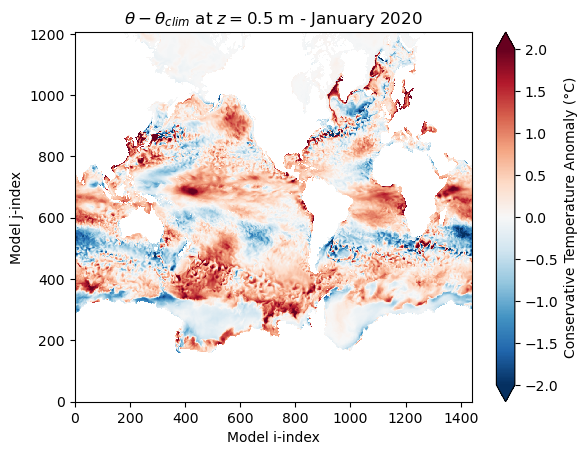

In [13]:
ds_mdl["thetao_con_anom"][0, 0, :, :].plot(vmin=-2, vmax=2, cmap="RdBu_r", cbar_kwargs={"label": "Conservative Temperature Anomaly (°C)"})

plt.title("$\\theta - \\theta_{clim}$ at $z = 0.5$ m - January 2020")
plt.xlabel("Model i-index")
plt.ylabel("Model j-index")

### Sampling - Argo Random Sampler

In [14]:
sampler = RandomSampler.from_config(config=config)
sampler

RandomSampler(error_kernels=[MockErrorKernel()])

In [15]:
ds_obs = sampler.sample(ds_mdl=ds_mdl)
ds_obs

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:04:55 ║ --> Completed: Collected probability distribution for historical Argo profile observations.
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:04:55 ║ --> Completed: Collected ocean model grid indices for synthetic profiles.
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:04:56 ║ --> Completed: Extracted synthetic profiles from ocean model dataset.
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:04:56 ║ --> Completed: Applied ErrorKernels to synthetic observations.


<xarray.Dataset> Size: 301MB
Dimensions:                 (profile_id: 120000, lev: 75)
Coordinates:
  * profile_id              (profile_id) int64 960kB 0 1 2 ... 119998 119999
    time                    (profile_id) datetime64[s] 960kB 2020-01-16T12:00...
    lat                     (profile_id) float32 480kB dask.array<chunksize=(120000,), meta=np.ndarray>
    lon                     (profile_id) float32 480kB dask.array<chunksize=(120000,), meta=np.ndarray>
    month                   (profile_id) int64 960kB 1 1 1 1 1 ... 12 12 12 12
    depth                   (lev) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: lev
Data variables:
    thetao_con              (profile_id, lev) float32 36MB dask.array<chunksize=(108720, 7), meta=np.ndarray>
    so_abs                  (profile_id, lev) float32 36MB dask.array<chunksize=(108720, 7), meta=np.ndarray>
    mask                    (lev, profile_id) int8 9MB ...
    thickcello              (lev, profile_id) float64 72MB ...
    thetao_con_climatology  (profile_id, lev) float32 36MB dask.array<chunksize=(120000, 75), meta=np.ndarray>
    thetao_con_anom         (profile_id, lev) float32 36MB dask.array<chunksize=(108720, 7), meta=np.ndarray>
    so_abs_climatology      (profile_id, lev) float32 36MB dask.array<chunksize=(120000, 75), meta=np.ndarray>
    so_abs_anom             (profile_id, lev) float32 36MB dask.array<chunksize=(108720, 7), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-18 20:40:28 GMT
    uuid:         069e56b4-7ad7-45f8-bd75-d5ecee73a4a7

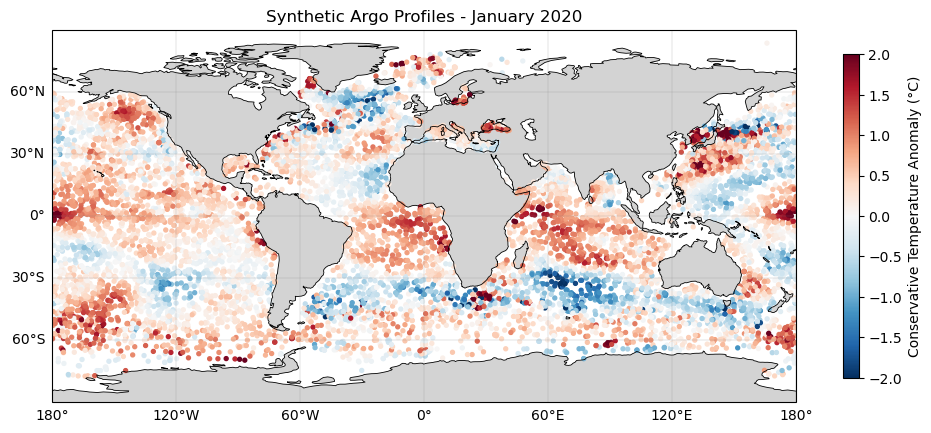

In [16]:
# Select January observations
jan = ds_obs.where(ds_obs.month == 1, drop=True)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Show the whole globe
ax.set_global()

# Add land and coastlines
ax.add_feature(cfeature.LAND, facecolor="lightgrey", edgecolor="none")
ax.coastlines(linewidth=0.6)

# Plot observations
sc = ax.scatter(
    jan["lon"],
    jan["lat"],
    c=jan.isel(lev=0)["thetao_con_anom"],
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    s=8,
    transform=ccrs.PlateCarree(),   # coordinates are lon/lat
)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colourbar
plt.colorbar(sc, ax=ax, label="Conservative Temperature Anomaly (°C)", shrink=0.7)

plt.title("Synthetic Argo Profiles - January 2020")
plt.show()

### Regridding - Inverse Distance Weighted Regridding

In [17]:
regridder = IDWRegridder.from_config(config=config)
regridder

IDWRegridder(variables=['thetao_con', 'so_abs'])

In [18]:
ds_obs_regridded = regridder.regrid(ds_obs=ds_obs, ds_mdl=ds_mdl)
ds_obs_regridded

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:10:41 ║ Completed: Loaded synthetic profiles and model grid data.
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:10:41 ║ In Progress: Regridding variable `thetao_con` using pyinterp.inverse_distance_weighting.
Interpolation Progress: 100%|██████████| 12/12 [02:24<00:00, 12.01s/time-step]
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:13:05 ║ In Progress: Regridding variable `so_abs` using pyinterp.inverse_distance_weighting.
Interpolation Progress: 100%|██████████| 12/12 [02:24<00:00, 12.05s/time-step]
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-24 08:15:30 ║ Completed: Regridded variable `so_abs` using pyinterp.inverse_distance_weighting.


<xarray.Dataset> Size: 13GB
Dimensions:                 (time: 12, j: 1206, i: 1440, lev: 75)
Coordinates:
  * time                    (time) datetime64[s] 96B 2020-01-16T12:00:00 ... ...
    month                   (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lat                     (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon                     (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    depth                   (lev) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: j, i, lev
Data variables:
    thetao_con_anom_regrid  (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs_anom_regrid      (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>

In [19]:
# Reconstruct the field by adding the monthly climatology back to the regridded anomalies:
ds_obs_regridded["thetao_con_regrid"] = ds_obs_regridded["thetao_con_anom_regrid"].fillna(0).where(ds_mdl["mask"]) + ds_mdl["thetao_con_climatology"]
ds_obs_regridded["so_abs_regrid"] = ds_obs_regridded["so_abs_anom_regrid"].fillna(0).where(ds_mdl["mask"]) + ds_mdl["so_abs_climatology"]

ds_obs_regridded

<xarray.Dataset> Size: 25GB
Dimensions:                 (time: 12, j: 1206, i: 1440, lev: 75)
Coordinates:
  * time                    (time) datetime64[s] 96B 2020-01-16T12:00:00 ... ...
    month                   (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lat                     (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    lon                     (j, i) float32 7MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    depth                   (lev) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: j, i, lev
Data variables:
    thetao_con_anom_regrid  (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs_anom_regrid      (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    thetao_con_regrid       (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>
    so_abs_regrid           (time, lev, j, i) float32 6GB dask.array<chunksize=(1, 7, 151, 720), meta=np.ndarray>

Text(0, 0.5, 'Model j-index')

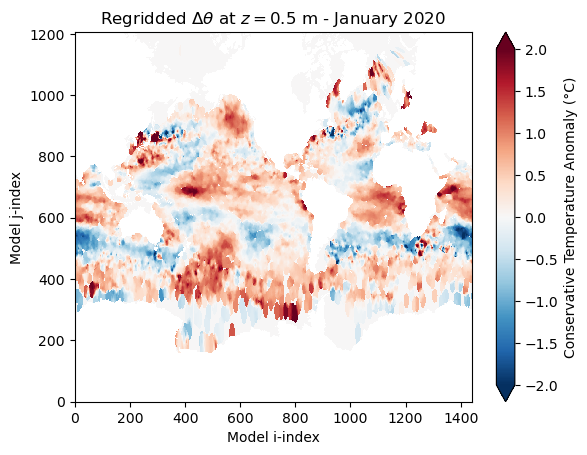

In [ ]:
ds_obs_regridded["thetao_con_anom_regrid"].fillna(0).where(ds_mdl["mask"])[0, 0, :, :].plot(vmin=-2, vmax=2, cmap="RdBu_r", cbar_kwargs={"label": "Conservative Temperature Anomaly (°C)"})

plt.title("Regridded $ \\Delta \\theta$ at $z = 0.5$ m - January 2020")
plt.xlabel("Model i-index")
plt.ylabel("Model j-index")

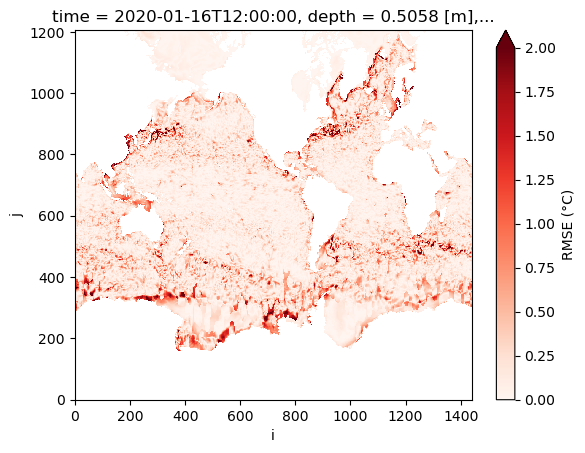

In [ ]:
import numpy as np

rmse = np.sqrt((ds_obs_regridded["thetao_con_anom_regrid"].fillna(0).where(ds_mdl["mask"]) - ds_mdl["thetao_con_anom"])**2)

rmse[0, 0, :, :].plot(vmin=0, vmax=2, cmap="Reds", cbar_kwargs={"label": "RMSE (°C)"})



Text(0, 0.5, 'Model j-index')

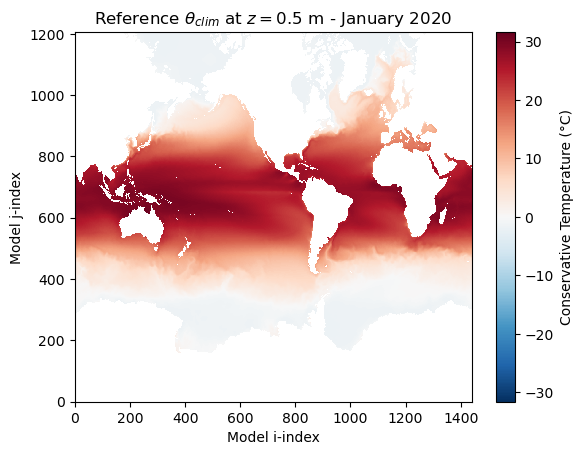

In [24]:
ds_mdl["thetao_con_climatology"][0, 0, :, :].plot(cmap="RdBu_r", cbar_kwargs={"label": "Conservative Temperature (°C)"})

plt.title("Reference $\\theta_{clim}$ at $z = 0.5$ m - January 2020")
plt.xlabel("Model i-index")
plt.ylabel("Model j-index")

Text(0, 0.5, 'Model j-index')

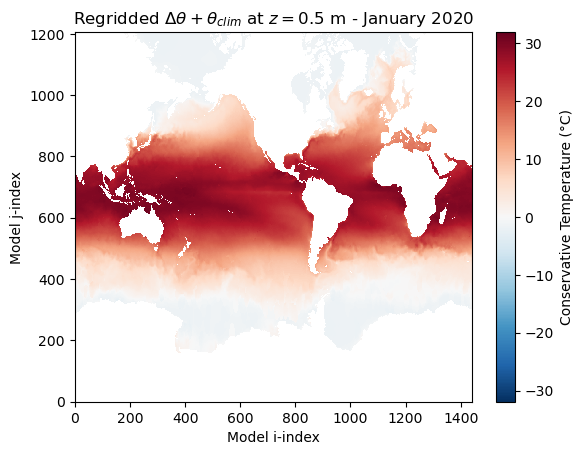

In [22]:
ds_obs_regridded["thetao_con_regrid"][0, 0, :, :].plot(cmap="RdBu_r", cbar_kwargs={"label": "Conservative Temperature (°C)"})

plt.title("Regridded $\\Delta \\theta + \\theta_{clim}$ at $z = 0.5$ m - January 2020")
plt.xlabel("Model i-index")
plt.ylabel("Model j-index")

### Data Writers - NetCDFWriter

In [ ]:
datawriter = NetCDFDataWriter.from_config(config=config)
datawriter.write_data(ds=ds_obs_regridded[["thetao_con_regrid", "so_abs_regrid"]])
datawriter

### Convective Adjustment [Optional]

In [ ]:
# Verify output Dataset:
ds_out = xr.open_dataset(
    "/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE/eORCA025_ERA5v1_2020-01-2020-12.nc"
).rename({"time_counter": "time", "deptht": "lev", "y": "j", "x": "i"}).chunk({"lev": -1})

ds_out

In [ ]:
from OceanOSSE.gridding.convective_adjustment import convective_adjustment

ds_out["so_abs_regrid_adj"], ds_out["thetao_con_regrid_adj"] = convective_adjustment(SA=ds_out["so_abs_regrid"],
                                                                                     CT=ds_out["thetao_con_regrid"],
                                                                                     p=ds_mdl["depth"].chunk({"lev": -1}),
                                                                                     h=ds_mdl["e3t_0"].chunk({"lev": -1}),
                                                                                     dim="lev"
                                                                                     )

### RAPID 26.5N Section

In [ ]:
ds_mdl["thetao_con"].isel(j=228, i=slice(206, 280), time=0).plot(yincrease=False, y="depth")

In [ ]:
(ds_obs_regridded["thetao_con_regrid"].isel(j=228, i=slice(206, 280), time=6) - ds_mdl["thetao_con"].isel(j=228, i=slice(206, 280), time=6)).plot(yincrease=False)

### Variance Analysis

In [ ]:
ds_obs_regridded["thetao_con_anom_regrid"].fillna(0).where(ds_mdl["mask"])[0, 0, :, :].plot(cmap="RdBu_r")

In [ ]:
(ds_obs_regridded["thetao_con_regrid"][0, 0, :, :] - ds_mdl["thetao_con"][0, 0, :, :]).plot()

In [ ]:
var_mdl = ds_mdl["thetao_con"].where(ds_mdl["mask"]).sel(time=slice("2020-01", "2020-12")).var(dim="time")
var_mdl[0, :, :].plot()

In [ ]:
var_regrid = ds_obs_regridded["thetao_con_regrid"].fillna(0).where(ds_mdl["mask"]).var(dim="time")
var_regrid[0, :, :].plot()

In [ ]:
(var_regrid[0, :, :] - var_mdl[0, :, :]).plot(cmap="RdBu_r")